# Anomaly Correlation Coefficient (ACC)

**Did the forecast put the warmer-than-normal and cooler-than-normal conditions in the right places?**

ACC answers this question by comparing forecast and observed *anomalies*: their departures from climatology. This is useful when the usual differences between locations dominate the raw values. A forecast can reproduce those usual differences while missing today's unusual conditions.

Here we use four equally weighted locations with different normal temperatures and two forecasts: one predicts the opposite anomalies; the other predicts the correct pattern but makes the anomalies three times too strong.

See the [API documentation](../api.md#scores.continuous.correlation.anomaly_correlation_coefficient) for more information on the various args.

In [11]:
import matplotlib.pyplot as plt
import xarray as xr

from scores.continuous import rmse
from scores.continuous.correlation import anomaly_correlation_coefficient, pearsonr

# Synthetic temperatures (degrees Celsius) for one day.
climatology = xr.DataArray(
    [30.0, 20.0, 10.0, 0.0], dims="location", coords={"location": ["A", "B", "C", "D"]}
)
observed_anomaly = xr.DataArray([2.0, -2.0, -2.0, 2.0], dims="location")
obs = climatology + observed_anomaly
fcst = xr.concat(
    [climatology - observed_anomaly, climatology + 3 * observed_anomaly],
    dim=xr.IndexVariable("forecast", ["Opposite anomalies", "Three times too strong"]),
)

The raw temperatures all follow the same warm-to-cool gradient. Subtracting climatology reveals which forecast captures the departures from normal.

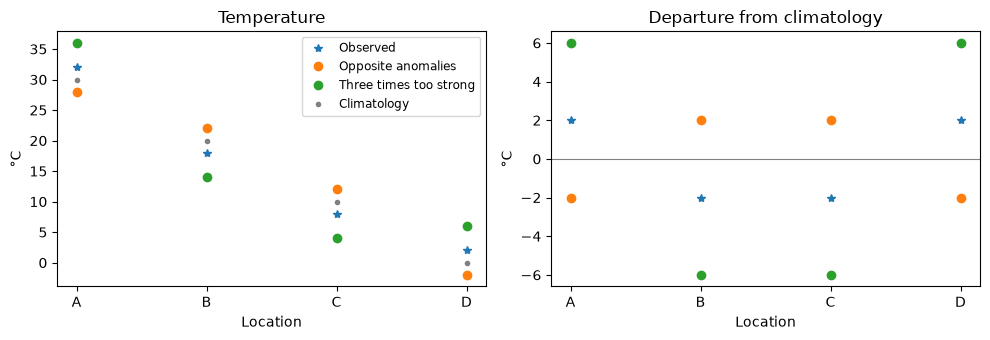

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, reference, title in zip(
    axes, [0, climatology], ["Temperature", "Departure from climatology"]
):
    ax.plot(obs.location, obs - reference, "*", label="Observed")
    for name in fcst.forecast.values:
        ax.plot(fcst.location, fcst.sel(forecast=name) - reference, "o", label=name)
    ax.set(title=title, xlabel="Location", ylabel="°C")
axes[0].plot(climatology.location, climatology, ".", color="grey", label="Climatology")
axes[0].legend(fontsize="small")
axes[1].axhline(0, color="grey", linewidth=0.8)
fig.tight_layout()
plt.show()

Let's reduce the `location` dimension to get one score per forecast and compare ACC with Pearson correlation of the raw temperatures and RMSE.

In [13]:
xr.Dataset(
    {
        "Raw Pearson correlation": pearsonr(fcst, obs, reduce_dims="location"),
        "ACC": anomaly_correlation_coefficient(fcst, obs, climatology, reduce_dims="location"),
        "RMSE (°C)": rmse(fcst, obs, reduce_dims="location"),
    }
).to_dataframe().round(3)

,Raw Pearson correlation,ACC,RMSE (°C)
forecast,,,
Opposite anomalies,0.938,-1.0,4.0
Three times too strong,0.951,1.0,4.0


Both raw correlations exceed 0.9, even though the first forecast predicts the opposite anomalies. ACC exposes this difference: **−1** for opposite anomalies and **1** for the correct pattern at three times the strength. An ACC of **0** indicates no alignment between the anomaly fields.

Both forecasts have RMSE **4 °C**. ACC distinguishes their pattern agreement, while RMSE shows that even the forecast with ACC 1 has substantial temperature errors. Use both when pattern and magnitude matter.


## Centred and uncentred ACC

The default, `centered=False`, calculates uncentred ACC. It subtracts climatology, then compares the resulting anomalies without removing their sample means. With forecast anomalies $a_i=f_i-c_i$ and observed anomalies $b_i=o_i-c_i$,

$$\mathrm{ACC}_{u}=\frac{\sum_i w_i a_i b_i}{\sqrt{\sum_i w_i a_i^2}\sqrt{\sum_i w_i b_i^2}}.$$

To calculate the centred ACC, set `centered=True`. It also subtracts each anomaly field's own mean over the dimensions being reduced:

$$\bar{a}_w=\frac{\sum_i w_i a_i}{\sum_i w_i},\qquad
\bar{b}_w=\frac{\sum_i w_i b_i}{\sum_i w_i},$$

$$\mathrm{ACC}_{c}=\frac{\sum_i w_i(a_i-\bar{a}_w)(b_i-\bar{b}_w)}{\sqrt{\sum_i w_i(a_i-\bar{a}_w)^2}\sqrt{\sum_i w_i(b_i-\bar{b}_w)^2}}.$$

Weights default to 1.

Centred ACC is Pearson correlation of the anomalies (see the [Pearson's Correlation tutorial](./Pearsons_Correlation.ipynb)), which can differ from Pearson correlation of the raw temperatures when climatology varies between locations. Centring removes a uniform offset in either anomaly field. Uncentred ACC retains the mean departures from climatology, so a uniform offset can change its value. Neither version measures amplitude errors: multiplying an anomaly field by a positive constant leaves its ACC unchanged.

Our first two forecasts have zero mean anomalies, so the two versions agree. To see the difference, we add a forecast that is 4 °C too warm everywhere, with the correct spatial variations.

In [14]:
comparison_fcst = xr.concat(
    [fcst, (obs + 4).expand_dims(forecast=["Uniform warm offset"])], dim="forecast"
)
comparison = xr.Dataset(
    {
        "Uncentred ACC": anomaly_correlation_coefficient(
            comparison_fcst, obs, climatology, reduce_dims="location"
        ),
        "Centred ACC": anomaly_correlation_coefficient(
            comparison_fcst, obs, climatology, centered=True, reduce_dims="location"
        ),
        "RMSE (°C)": rmse(comparison_fcst, obs, reduce_dims="location"),
    }
)
comparison.to_dataframe().round(3)


,Uncentred ACC,Centred ACC,RMSE (°C)
forecast,,,
Opposite anomalies,-1.000,-1.0,4.0
Three times too strong,1.000,1.0,4.0
Uniform warm offset,0.447,1.0,4.0


The forecast with a uniform warm offset has centred ACC 1, because its anomalies differ from the observed anomalies only by a constant. Its uncentred ACC is about 0.447: the mean departure from climatology changes the alignment. Its RMSE is still 4 °C.

Use centred ACC when you want to assess spatial variations after removing each field's mean anomaly over the verification region. Use uncentred ACC when you want the comparison to retain those mean departures.


## Things to try next

Change the anomaly multiplier from 3 to 1, or change the uniform warm offset from 4 to 0. Which scores change? Then supply unequal location weights (see the [Weighting Results tutorial](./Weighting_Results.ipynb)): the weighted mean anomalies may no longer be zero, so the two forms need not agree even for the original examples.

Test out ACC with some real weather prediction model data and corresponding observations. See the [Dimension Handling tutorial](./Dimension_Handling.ipynb) for more on the `reduce_dims` and `preserve_dims` arguments used throughout this tutorial.

## Further reading

- WWRP/WGNE Joint Working Group on Forecast Verification Research. (n.d.). *Forecast verification: Methods, issues and FAQ*. https://jwgfvr.github.io/forecastverification/

- Jolliffe, I. T., & Stephenson, D. B. (Eds.). (2012). *Forecast verification: A practitioner's guide in atmospheric science* (2nd ed.). Wiley. https://doi.org/10.1002/9781119960003